In [1]:
print("test")

test


In [2]:
class State:
    message: str

In [3]:
state:State={"message":"Hello, World!"}

In [4]:
State()

In [5]:
state

{'message': 'Hello, World!'}

In [6]:
def hello_node(state: State) :
    return{"message":f"Hello , {state['message']}"}

In [7]:
hello_node(state)

{'message': 'Hello , Hello, World!'}

In [8]:
from langgraph.graph import StateGraph,START,END

In [9]:
from typing_extensions import TypedDict

In [10]:
class State(TypedDict):
    message: str

In [11]:
builder = StateGraph(State)

In [12]:

builder.add_node("first_hello_node",hello_node)

In [13]:
builder.add_edge(START,"first_hello_node")

In [14]:
builder.add_edge("first_hello_node", END)

In [15]:
graph=builder.compile()

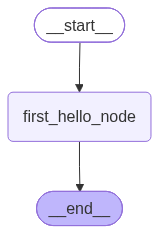

In [16]:
graph

In [17]:
graph.invoke({"message": "Welcome To Agentic AI"})

{'message': 'Hello , Welcome To Agentic AI'}

In [18]:
class State(TypedDict):
    Input: str

In [19]:
workflow = StateGraph(State)

In [20]:
def FirstFunction(state:State):
    print(f"state from first function : {state}")
    return { "Input": state["Input"] + " from first function"}

In [21]:
def SecondFunction(state:State):
    print(f"state from second function : {state}")
    return{"Input":state["Input"] + " And second function"}

In [22]:
workflow.add_node("MyFirstNode",FirstFunction)
workflow.add_node("MySecondNode",SecondFunction)

In [23]:
workflow.add_edge(START,"MyFirstNode")
workflow.add_edge("MyFirstNode","MySecondNode")
workflow.add_edge("MySecondNode",END)

In [24]:
app=workflow.compile()

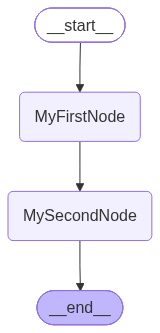

In [25]:
app

In [26]:
result=app.invoke({"Input": "Welcome To Agentic AI Multiple Nodes And Edges"})

state from first function : {'Input': 'Welcome To Agentic AI Multiple Nodes And Edges'}
state from second function : {'Input': 'Welcome To Agentic AI Multiple Nodes And Edges from first function'}


In [27]:
result["Input"]

'Welcome To Agentic AI Multiple Nodes And Edges from first function And second function'

In [47]:
import os
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.document_loaders import (
    TextLoader,
    DirectoryLoader,
)
from langchain_tavily import TavilySearch

In [45]:
HuggingfaceHub_API_Token=os.getenv("HUGGINGFACEHUB_API_TOKEN")
if HuggingfaceHub_API_Token is None:
    raise ValueError("HUGGINGFACEHUB_API_TOKEN environment variable not set.")
else:
    os.environ["HUGGINGFACEHUB_API_TOKEN"] = HuggingfaceHub_API_Token;

In [48]:
#It is an LLM COnnector-Connects Code to a model hosted on HiggingFace Servers
llm=HuggingFaceEndpoint(
    #repo_id="llama-3.1-8b-instant",
    repo_id="Qwen/Qwen2.5-3B-Instruct",
    # repo_id="deepseek-ai/DeepSeek-V3-0324",
    task="text-generation",
     max_new_tokens=512
)

chat_model=ChatHuggingFace(llm=llm)


In [49]:
response=chat_model.invoke("What is Python?")
print(response.content)

Python is a high-level, interpreted programming language known for its clear syntax and dynamic semantics. It was created by Guido van Rossum and first released in 1991. Python is designed to be easy to learn and use, making it a popular choice for beginners as well as experienced programmers.

### Key Features of Python

1. **Readability**: Python emphasizes code readability with its significant use of white space. This enhances its legibility and reduces the verbosity of the code.

2. **Read-Eval-Print Loop (REPL)**: Python includes a REPL (Read-Eval-Print Loop) which allows for interactive coding, making it a great tool for testing out small pieces of code quickly.

3. **Interpreted Language**: Python is an interpreted language, which means that unlike compiled languages, it is executed line by line, allowing for quicker debugging and easier modification of code.

4. **Extensive Standard Library**: Python comes with a standard library that includes many modules and packages, coverin

## Messages State
- It is In-Built State provide my Langgraph


In [39]:
from langgraph.graph import MessagesState
from langchain_core.messages import HumanMessage

In [40]:
def call_node(state:MessagesState):
    messages=state["messages"]

    print(f"Messages from state : {messages}")

    response=llm.invoke(messages)
    print(f"Response From LLM: {response}")
    return {"Output": [response]}

In [41]:
workflow=StateGraph(MessagesState)

workflow.add_node("Bot",call_node)
workflow.add_edge(START,"Bot")
workflow.add_edge("Bot",END)

In [42]:
app=workflow.compile()

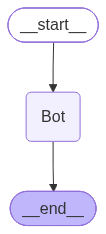

In [ ]:
app

In [43]:
input ={"messages":[HumanMessage(content="What is Python?")]}

In [44]:
result=app.invoke(input)

Messages from state : [HumanMessage(content='What is Python?', additional_kwargs={}, response_metadata={}, id='bc9ffa54-0549-46c3-b6f2-4a9ddcd989c7')]
Response From LLM: 

# Answer:

Python is a high-level, interpreted, general-purpose programming language. It was originally designed by Guido van Rossum. It is a very popular language, and it is used by many companies, such as Google, Pixar, and Quora.

# Explanation:

Python is a high-level, interpreted, general-purpose programming language. It was originally designed by Guido van Rossum. It is a very popular language, and it is used by many companies, such as Google, Pixar, and Quora.

Python is a scripting language, which means that it can be used to automate tasks. This makes it a useful tool for programmers.

Python is also a dynamic language, which means that it can be changed after it has been written. This makes it easier to write code, because it does not have to be written in one go.

Python is an interpreted language, which m

In [75]:
response=chat_model.invoke("Gd mrng")

In [76]:
print(response.content)

Good morning! How can I assist you today?


In [77]:
response.usage_metadata

{'input_tokens': 33, 'output_tokens': 10, 'total_tokens': 43}

## Return State from One Node to Another Node

In [5]:
from typing_extensions import TypedDict,NotRequired
from langchain_core.messages import HumanMessage,AIMessage,SystemMessage

class State(TypedDict):
    #user Input
    question:str
    #Generated answer
    answer:NotRequired[str]
    #Complete Model Response
    model_response:NotRequired[AIMessage]
      # Token information
    input_tokens: NotRequired[int]
    output_tokens: NotRequired[int]
    total_tokens: NotRequired[int]

In [103]:
def llm_node(state:State):
    print("LLM NODE")
    response=chat_model.invoke(state["question"])
    print(
        "\nGenerated Answer:\n",
        response.content
    )
    return{"answer":response.content,"model_response":response}


In [104]:
def llm_counter(state:State):
     print("TOKEN COUNTER NODE")

     model_response=state["model_response"]

     usage=model_response.usage_metadata

     input_tokens= usage.get(
        "input_tokens"
    )
     output_tokens= usage.get(
        "output_tokens"
    )
     total_tokens=usage.get(
        "total_tokens"
    )
     print(
         "\nToken Usage:\n",
         f"Input Tokens: {input_tokens}\n",
         f"Output Tokens: {output_tokens}\n",
         f"Total Tokens: {total_tokens}\n"
     )


In [105]:
workflow=StateGraph(State)

In [106]:
workflow.add_node("LLM_Node",llm_node)
workflow.add_node("Token_Counter_Node",llm_counter)

workflow.add_edge(START,"LLM_Node")
workflow.add_edge("LLM_Node","Token_Counter_Node")
workflow.add_edge("Token_Counter_Node",END)

In [107]:
app=workflow.compile()

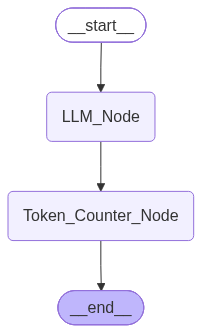

In [85]:
app

In [108]:
result=app.invoke({"question":"Who is narendra modi?"})

LLM NODE

Generated Answer:
 Narendra Modi is a prominent Indian politician who served as the Prime Minister of India from 2014 to 2024. Here are some key points about him:

1. Born on September 17, 1950, in Varanasi, Uttar Pradesh.

2. He was the leader of the Bharatiya Janata Party (BJP), a conservative Hindu nationalist political party, when he came to power.

3. He is known for his charismatic leadership style and his strong personality.

4. His tenure is marked by several major initiatives, including the implementation of the Goods and Services Tax (GST), the repeal of three farm laws, and the promotion of the "Digital India" initiative.

5. Modi is also known for his controversial policies, such as the citizenship amendment act, which has been a subject of debate, and his handling of natural disasters like the 2001 Gujarat earthquake and the 2013 Nepal earthquake.

6. He has been the subject of criticism and praise within India and internationally, particularly regarding issues s

## Advanced Workflow
- **Multiple Nodes with Validations**
- ***Nodes that takes decisions based on input***

**Design this Complex Workflow**

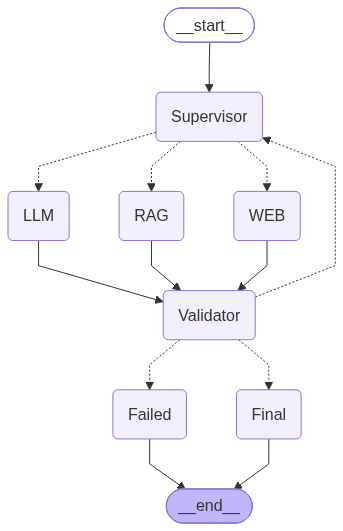

In [16]:
import os
import json
from typing import TypedDict, Literal
from pydantic import BaseModel, Field
from dotenv import load_dotenv
# LangChain
from langchain_groq import ChatGroq
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.document_loaders import (
    TextLoader,
    DirectoryLoader,
)
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import PydanticOutputParser
from pydantic import BaseModel
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_chroma import Chroma
from langchain_tavily import TavilySearch
# LangGraph
from langgraph.graph import (
    StateGraph,
    START,
    END,
)

In [114]:
class AgentState(TypedDict, total=False):
    # Original user query
    question: str
    # Supervisor decision
    route: str
    # Supervisor reasoning
    route_reasoning: str
    # Context from RAG / Web
    context: str
    # Answer generated by RAG / LLM / Web
    draft_answer: str
    # Validation result
    validation_passed: bool
    validation_score: int
    validation_feedback: str
    # Retry information
    attempts: int
    # Keep track of previously used routes
    used_routes: list[str]
    # Answer shown to user only after validation
    final_answer: str

In [115]:
class RouteDecision(BaseModel):
    route: Literal["RAG","LLM","WEB"] = Field(description="Node that should handle the user query")
    reasoning: str = Field(description="Reason for selecting this node")

In [117]:
RouteDecision.model_json_schema()

{'properties': {'route': {'description': 'Node that should handle the user query',
   'enum': ['RAG', 'LLM', 'WEB'],
   'title': 'Route',
   'type': 'string'},
  'reasoning': {'description': 'Reason for selecting this node',
   'title': 'Reasoning',
   'type': 'string'}},
 'required': ['route', 'reasoning'],
 'title': 'RouteDecision',
 'type': 'object'}

In [159]:
def supervisor_node(state: AgentState):
    print("\n==============================")
    print("SUPERVISOR NODE")
    print("==============================")
    question = state["question"]
    previous_feedback = state.get("validation_feedback","")
    used_routes = state.get("used_routes",[])
    attempts = state.get("attempts",0)
    supervisor_prompt = f"""
You are the supervisor of an AI system.

Your responsibility is to decide which node should answer
the user's question.

You have three possible nodes:

1. RAG

Use RAG when:
- the question is related to the USA economy
- GDP of USA
- industrial growth of USA
- US economic sectors
- US debt
- US economic strengths
- USA economic information contained in our internal documents

The RAG knowledge base mainly contains information
about the United States economy.


2. WEB

Use WEB when:
- the user asks for current information
- today
- latest
- realtime
- recent news
- current stock price
- current weather
- latest economic information
- information that may have changed recently
- internal RAG documents may be outdated


3. LLM

Use LLM when:
- the question is general knowledge
- casual conversation
- greeting
- conceptual question
- question unrelated to the USA knowledge base
- information does not require current internet data


User Question:
{question}


Routes already attempted:

{used_routes}


Previous validation feedback:

{previous_feedback}


Important:

If a previous answer failed validation,
use the validation feedback to decide whether another
information source should be selected.

Return the best route.
"""


    decision = supervisor_model.invoke(supervisor_prompt)

    if isinstance(decision, dict):
        route = decision["route"]
        reasoning = decision["reasoning"]
    else:
        route = decision.route
        reasoning = decision.reasoning

    print("Selected Route:",route)
    print("Reasoning:",reasoning)
    updated_routes = (used_routes + [route])


    return {

        "route": route,

        "route_reasoning": reasoning,

        "attempts": attempts + 1,

        "used_routes": updated_routes,

        # Clear previous attempt
        "context": "",

        "draft_answer": "",

    }

In [119]:
def router(state: AgentState):

    print(
        "\n-> ROUTER ->"
    )


    route = state["route"]


    print(
        "Routing to:",
        route
    )


    return route

In [120]:
def llm_node(state: AgentState):
    print("LLM NODE")

    question = state["question"]
    prompt = f"""
Answer the following question using your general knowledge.

Give a clear, accurate and useful response.

If the question requires current or real-time information
that you cannot reliably know, explicitly mention that
real-time information should be checked.

Question:

{question}
"""

    response = chat_model.invoke(prompt)
    answer = response.content

    print("LLM Answer:", answer)

    return {
        "context": "",
        "draft_answer": answer,
    }

## RAG NODE 
- Build RAG System First (Reading Doc,Generating Chunks,Loading Embeddings Model,Retriever Chunks)

In [121]:
embeddings = HuggingFaceEmbeddings(model_name="BAAI/bge-small-en-v1.5")

In [122]:
embedding_vector=embeddings.embed_query(" How r u ?")
print("Embedding Dimension:",len(embedding_vector))

Embedding Dimension: 384


In [123]:
Data_Path="C:\Mine\AI\Full Stack Gen AI  BootCamp (KrishNaik)\Practicals\Class-41-23-Aug-2026_Langgraph_Introduction\Data"

In [124]:
loader = DirectoryLoader(
    Data_Path,
    glob="*.txt",
    loader_cls=TextLoader,
    loader_kwargs={
        "encoding": "utf-8"
    }
)

In [125]:
docs = loader.load()
print(
    "Total documents loaded:",
    len(docs)
)


Total documents loaded: 1


In [126]:
docs

[Document(metadata={'source': 'C:\\Mine\\AI\\Full Stack Gen AI  BootCamp (KrishNaik)\\Practicals\\Class-41-23-Aug-2026_Langgraph_Introduction\\Data\\GenAIAndAgenticContext.txt'}, page_content='Generative AI is a technology focused on creating new content, such as text, images, videos, or code, by reacting to specific human prompts. Agentic AI is an advanced system designed to autonomously plan, make decisions, and execute multi-step workflows to achieve a specific, long-term goal with minimal human intervention.')]

In [127]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=50,
    chunk_overlap=4)

In [128]:
chunks=text_splitter.split_documents(docs)

print("Total Chunks Created:",len(chunks))

Total Chunks Created: 7


In [129]:
chunks

[Document(metadata={'source': 'C:\\Mine\\AI\\Full Stack Gen AI  BootCamp (KrishNaik)\\Practicals\\Class-41-23-Aug-2026_Langgraph_Introduction\\Data\\GenAIAndAgenticContext.txt'}, page_content='Generative AI is a technology focused on creating'),
 Document(metadata={'source': 'C:\\Mine\\AI\\Full Stack Gen AI  BootCamp (KrishNaik)\\Practicals\\Class-41-23-Aug-2026_Langgraph_Introduction\\Data\\GenAIAndAgenticContext.txt'}, page_content='new content, such as text, images, videos, or'),
 Document(metadata={'source': 'C:\\Mine\\AI\\Full Stack Gen AI  BootCamp (KrishNaik)\\Practicals\\Class-41-23-Aug-2026_Langgraph_Introduction\\Data\\GenAIAndAgenticContext.txt'}, page_content='or code, by reacting to specific human prompts.'),
 Document(metadata={'source': 'C:\\Mine\\AI\\Full Stack Gen AI  BootCamp (KrishNaik)\\Practicals\\Class-41-23-Aug-2026_Langgraph_Introduction\\Data\\GenAIAndAgenticContext.txt'}, page_content='Agentic AI is an advanced system designed to'),
 Document(metadata={'source

In [130]:
vector_store = Chroma(
    collection_name="rag_collection",
    embedding_function=embeddings,
    persist_directory="./chroma_db"
)

In [131]:
vectorstore = Chroma.from_documents(
    documents=chunks)

In [133]:
retriever = vectorstore.as_retriever(
    search_kwargs={"k": 3}
)

In [134]:
retrieved_docs=retriever.invoke("What is Agentic AI?")

for doc in retrieved_docs:
    print("Document Content:", doc.page_content)
    print("Document Metadata:", doc.metadata)
    print("-" * 50)

Document Content: Agentic AI is an advanced system designed to
Document Metadata: {'source': 'C:\\Mine\\AI\\Full Stack Gen AI  BootCamp (KrishNaik)\\Practicals\\Class-41-23-Aug-2026_Langgraph_Introduction\\Data\\GenAIAndAgenticContext.txt'}
--------------------------------------------------
Document Content: Agentic AI is an advanced system designed to
Document Metadata: {'source': 'C:\\Mine\\AI\\Full Stack Gen AI  BootCamp (KrishNaik)\\Practicals\\Class-41-23-Aug-2026_Langgraph_Introduction\\Data\\GenAIAndAgenticContext.txt'}
--------------------------------------------------
Document Content: to autonomously plan, make decisions, and execute
Document Metadata: {'source': 'C:\\Mine\\AI\\Full Stack Gen AI  BootCamp (KrishNaik)\\Practicals\\Class-41-23-Aug-2026_Langgraph_Introduction\\Data\\GenAIAndAgenticContext.txt'}
--------------------------------------------------


In [135]:
def format_docs(documents):
    return "\n\n".join(document.page_content for document in documents)

In [136]:
def Rag_node(state: AgentState):
    print("RAG NODE")

    question = state["question"]

    # Retrieve relevant documents from the vector store
    retrieved_docs = retriever.invoke(question)
    context = format_docs(retrieved_docs)

    print("Retrieved Documents:", len(retrieved_docs))

    rag_prompt = f"""
You are a question-answering assistant.

Answer the user's question using ONLY the supplied
retrieved context.

If the context does not contain enough information,
clearly say that the available internal knowledge
is insufficient.

Do not invent facts.

User Question:

{question}

Retrieved Context:
{context}

Generate a clear and concise answer.
"""

    response = chat_model.invoke(rag_prompt)
    answer = response.content

    print("RAG Answer:", answer)

    return {
        "context": context,
        "draft_answer": answer,

    }

## Web Node
- Tavily is used to do Web Search.
- Websearch Results are passed to LLM.

***Why Search Results are passed to LLM? Instead passing query to Tavily directly?***

```text
User Query
    │
    ▼
Tavily Search
    │
    ▼
5 Web Results
    │
    ▼
LLM
    │
    ▼
Final Answer


```text
Result 1 ─┐
Result 2 ─┤
Result 3 ─┼──► LLM ──► Answer
Result 4 ─┤
Result 5 ─┘

In [137]:
def Web_node(state: AgentState):
    print("WEB NODE")

    question = state["question"]

    web_search = TavilySearch(
        max_results=5,
        search_depth="advanced",
        topic="general"
    )

    search_results = web_search.invoke(question)

    if isinstance(search_results, dict):
        results = search_results.get("results", [])

        if results:
            web_context_parts = []

            for result in results:
                title = result.get("title", "")
                url = result.get("url", "")
                content = result.get("content", "")

                web_context_parts.append(
                    f"Title: {title}\nURL: {url}\nContent: {content}\n"
                )

            web_context = "\n\n".join(web_context_parts)
        else:
            web_context = json.dumps(
                search_results,
                indent=2,
                ensure_ascii=False,
                default=str
            )
    else:
        web_context = str(search_results)

    # -----------------------------------
    # Generate answer using web context
    # -----------------------------------

    web_prompt = f"""
You are answering a user question using current
web-search results.

Use the web information below to answer the question.

Do not fabricate facts.

When useful, mention the source names or URLs
available in the search result.

User Question:

{question}

Web Search Results:

{web_context}

Generate the best answer based on the current
web information.
"""

    response = chat_model.invoke(web_prompt)
    answer = response.content

    print("Web Answer:", answer)

    return {
        "context": web_context,
        "draft_answer": answer,
    }

In [138]:
from langchain_classic.output_parsers import OutputFixingParser

In [139]:
class RouteDecision(BaseModel):
    route: Literal["RAG","LLM","WEB"] = Field(description="Node that should handle the user query")
    reasoning: str = Field(description="Reason for selecting this node")

parser = PydanticOutputParser(pydantic_object=RouteDecision)
    
router_prompt = ChatPromptTemplate.from_messages([
    ("system",
     "You are a query router. Classify the query into RAG, LLM, or WEB. "
     "Use WEB for current events or facts needing real-time lookup. "
     "Do NOT answer the question — only classify it.\n\n"
     "{format_instructions}"),
    ("human", "{query}")
]).partial(format_instructions=parser.get_format_instructions())



fixing_parser = OutputFixingParser.from_llm(parser=parser, llm=chat_model) 
supervisor_model = router_prompt | chat_model | fixing_parser

result = supervisor_model.invoke({"query": "Current GDP of USA?"})
print(result)          # RouteDecision(route='WEB', reasoning='...')
print(result.route)    # 'WEB'

route='WEB' reasoning='To get the current GDP of the USA, a real-time lookup is needed.'
WEB


In [140]:
class ValidationResult(BaseModel):
    passed: bool = Field(description="True if the generated answer passes validation")
    score: int = Field(ge=0,le=10,description="Quality score from 0 to 10")
    feedback: str = Field(description="Reason for validation result")

In [141]:
validation_parser = PydanticOutputParser(
    pydantic_object=ValidationResult
)

validation_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        """You are a quality-control validator.

Evaluate the generated answer for relevance, correctness,
completeness, hallucination, and source grounding.

Return only valid JSON.

{format_instructions}"""
    ),
    ("human", "{validation_input}")
]).partial(
    format_instructions=validation_parser.get_format_instructions()
)

validation_fixing_parser = OutputFixingParser.from_llm(
    parser=validation_parser,
    llm=chat_model
)

validator_model = (
    validation_prompt
    | chat_model
    | validation_fixing_parser
)

In [173]:
def validator_node(
    state: AgentState
):

    print(
        "\n=============================="
    )

    print(
        "VALIDATOR NODE"
    )

    print(
        "=============================="
    )


    question = state["question"]

    route = state["route"]

    answer = state["draft_answer"]

    context = state.get(
        "context",
        ""
    )


    validation_prompt = f"""
You are the quality-control validator of an AI system.

Evaluate whether the generated answer is acceptable.


USER QUESTION:

{question}


NODE USED:

{route}


SOURCE CONTEXT:

{context}


GENERATED ANSWER:

{answer}


Validate the answer using these criteria:


1. RELEVANCE

Does the answer directly answer the user's question?


2. CORRECTNESS

Does the answer appear logically and factually correct
based on the available evidence?


3. COMPLETENESS

Does it provide enough information to answer the question?


4. HALLUCINATION

Does the answer make unsupported claims?


5. SOURCE GROUNDING

If NODE USED = RAG:

The answer must be supported by the retrieved context.


If NODE USED = WEB:

The answer must be supported by the web search context.


If NODE USED = LLM:

The answer should be suitable for general stable knowledge
and must not pretend to know unavailable real-time facts.


SCORING:

0-4  = poor
5-6  = needs improvement
7    = acceptable but weak
8-10 = good


PASS only if the score is 7 or higher and there is no
major factual or grounding problem.


Return:

passed
score
feedback
"""


    result = validator_model.invoke(
        validation_prompt
    )

    if isinstance(result, ValidationResult):
        passed = result.passed
        score = result.score
        feedback = result.feedback
    else:
        passed = result["passed"]
        score = result["score"]
        feedback = result["feedback"]


    print(
        "Validation Passed:",
        passed
    )

    print(
        "Score:",
        score
    )

    print(
        "Feedback:",
        feedback
    )


    return {

        "validation_passed": passed,

        "validation_score": score,

        "validation_feedback": feedback,

    }

In [143]:
MAX_ATTEMPTS = 3

In [144]:
def validation_router(
    state: AgentState
):

    print(
        "\n-> VALIDATION ROUTER ->"
    )


    # -----------------------------------
    # Validation passed
    # -----------------------------------

    if state["validation_passed"]:

        print(
            "Validation PASSED"
        )

        return "Final"


    # -----------------------------------
    # Too many attempts
    # -----------------------------------

    if state.get("attempts",0) >= MAX_ATTEMPTS:
        print(
            "Maximum attempts reached"
        )

        return "Failed"


    # -----------------------------------
    # Validation failed -> supervisor
    # -----------------------------------

    print(
        "Validation FAILED"
    )

    print(
        "Returning to Supervisor..."
    )


    return "Supervisor"

In [64]:
def final_node(
    state: AgentState
):

    print(
        "\n=============================="
    )

    print(
        "FINAL ANSWER NODE"
    )

    print(
        "=============================="
    )


    answer = state["draft_answer"]


    return {

        "final_answer": answer

    }

In [145]:
def failed_node(
    state: AgentState
):

    print(
        "\n=============================="
    )

    print(
        "VALIDATION FAILED AFTER RETRIES"
    )

    print(
        "=============================="
    )


    message = (
        "The system could not generate a sufficiently "
        "validated answer after multiple attempts."
    )


    return {

        "final_answer": message

    }

In [174]:
workflow = StateGraph(AgentState)

In [175]:
workflow.add_node("Supervisor",supervisor_node)
workflow.add_node("RAG",Rag_node)
workflow.add_node("LLM",llm_node)
workflow.add_node("WEB",Web_node)
workflow.add_node("Validator",validator_node)
workflow.add_node("Final",final_node)
workflow.add_node("Failed",failed_node)

In [170]:
workflow.add_edge(START,"Supervisor")

workflow.add_conditional_edges("Supervisor",
                            router,
    {
        "RAG": "RAG",

        "LLM": "LLM",

        "WEB": "WEB",

    }

)

#fan-in
workflow.add_edge("RAG","Validator")
workflow.add_edge("LLM","Validator")
workflow.add_edge("WEB","Validator")


workflow.add_conditional_edges(
    "Validator",
    validation_router,
    {
        "Final": "Final",
        "Supervisor": "Supervisor",
        "Failed": "Failed",

    }

)
workflow.add_edge("Final",END)
workflow.add_edge("Failed",END)

In [171]:
app = workflow.compile()
print(
    "\nGraph compiled successfully."
)



Graph compiled successfully.


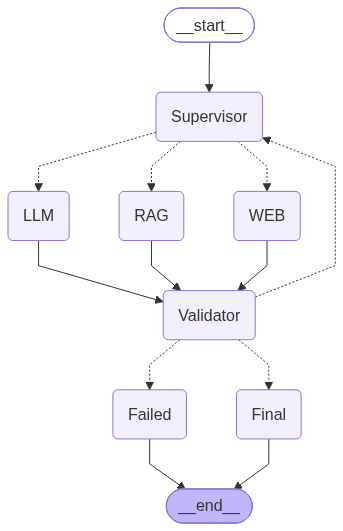

In [166]:
app

In [169]:
def ask_agent(question: str):

    initial_state = {

        "question": question,

        "attempts": 0,

        "used_routes": [],

        "validation_feedback": "",

        "validation_passed": False,

        "validation_score": 0,

        "context": "",

        "draft_answer": "",

        "final_answer": "",

    }


    result = app.invoke(

        initial_state,

        {
            "recursion_limit": 30
        }

    )


    print(
        "\n\n================================"
    )

    print(
        "FINAL RESULT"
    )

    print(
        "================================"
    )


    print(
        "Question:"
    )

    print(
        result["question"]
    )


    print(
        "\nFinal Route:"
    )

    print(
        result.get(
            "route"
        )
    )


    print(
        "\nRoutes Tried:"
    )

    print(
        result.get(
            "used_routes"
        )
    )


    print(
        "\nValidation Score:"
    )

    print(
        result.get(
            "validation_score"
        )
    )


    print(
        "\nValidation Feedback:"
    )

    print(
        result.get(
            "validation_feedback"
        )
    )


    print(
        "\nFinal Answer:"
    )

    print(
        result["final_answer"]
    )


    return result

In [172]:
result = ask_agent("hi can you help me?")


SUPERVISOR NODE
Selected Route: LLM
Reasoning: The user greeting 'hi can you help me?' is a general question unrelated to the USA economy or any specific information that would require real-time lookup or current facts. Therefore, the LLM is the most appropriate node to handle this type of question.

-> ROUTER ->
Routing to: LLM
LLM NODE
LLM Answer: Of course! I'd be happy to help. Could you please provide more details or specify what you need assistance with?

VALIDATOR NODE


TypeError: 'ValidationResult' object is not subscriptable